In [2]:
# importing necessary libraries
import tensorflow as tf
from keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32")/255.0
x_test = x_test.astype("float32")/255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# one hot encoding labels
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


**Sampling Layer**

In [6]:
latent_dim = 16
num_classes = 10

class Sampling(layers.Layer):
  def call(self, inputs):
    z_mean, z_log_var = inputs

    epsilon = tf.random.normal(
        shape=tf.shape(z_mean)
    )
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon   # latent vector



**Encoder**

In [7]:
image_input = layers.Input(shape=(784,))
label_input = layers.Input(shape=(num_classes,))

# encoder_input = [x, classes]
encoder_input = layers.Concatenate()(
    [image_input, label_input]
)

x = layers.Dense(256, activation="relu")(encoder_input)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model([image_input, label_input], [z_mean, z_log_var, z], name = "Encoder")



**Decoder**

In [8]:
latent_input = layers.Input(shape=(latent_dim,))
label_decoder = layers.Input(shape=(num_classes,))

# decoder_input = [z, classes]
decoder_input = layers.Concatenate()([latent_input, label_decoder])

x = layers.Dense(256, activation="relu")(decoder_input)

decoder_output = layers.Dense(
    784, activation="sigmoid"
)(x)

decoder = Model([latent_input, label_decoder], decoder_output, name="Decoder")

**CVAE Model**

In [10]:
class CVAE(Model):
  def __init__(self, encoder, decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder

  def call(self, inputs):
    image, label = inputs

    z_mean, z_log_var, z = self.encoder([image, label])
    reconstructed = self.decoder([z, label])
    return reconstructed

  def train_step(self, data):
    (image, label) = data[0]

    with tf.GradientTape() as tape:
      z_mean, z_log_var, z = self.encoder([image, label])
      reconstructed = self.decoder([z, label])
      reconstruction_loss = tf.reduce_mean(
          tf.keras.losses.binary_crossentropy(image, reconstructed)
          )
      kl_loss = -0.5 * tf.reduce_mean(
          1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
      )
      total_loss = ( reconstruction_loss + kl_loss )
      grads = tape.gradient(total_loss, self.trainable_weights)
      self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
      return {
          "loss": total_loss,
          "reconstruction_loss": reconstruction_loss,
          "kl_loss": kl_loss,
     }



**create CVAE**

In [11]:
cvae = CVAE(encoder, decoder)
cvae.compile(optimizer = "adam")

**Train CVAE**

In [12]:
history = cvae.fit(
    [x_train, y_train],
    epochs = 10,
    batch_size = 128
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - kl_loss: 2.2311e-05 - loss: 0.2280 - reconstruction_loss: 0.2280
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - kl_loss: 5.0290e-05 - loss: 0.2282 - reconstruction_loss: 0.2282
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - kl_loss: 5.1755e-05 - loss: 0.2277 - reconstruction_loss: 0.2277
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - kl_loss: 4.3229e-05 - loss: 0.2246 - reconstruction_loss: 0.2246
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - kl_loss: 3.0866e-05 - loss: 0.2235 - reconstruction_loss: 0.2234
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - kl_loss: 2.8113e-05 - loss: 0.2206 - reconstruction_loss: 0.2206
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - kl_loss: 1.5587e-05 - loss: 0.2217 - reconstruction_loss: 0.2217
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - kl_loss: 1.3971e-05 - loss: 0.2188 - reconstruction_loss: 0.2188
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━

**reconstruct test images**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


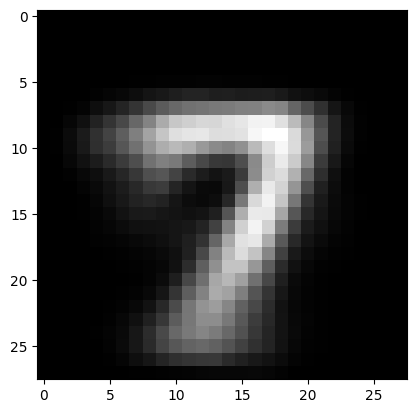

In [13]:
# Ranodom latent vector
z = np.random.normal(size = (1, latent_dim))

# label 7
label = tf.keras.utils.to_categorical([7], num_classes = 10)

generated = decoder.predict([z, label])
generated = generated.reshape(28, 28)

plt.imshow(generated, cmap = "gray")
plt.show()